<a href="https://colab.research.google.com/github/HoangThai2k5/THDeepLearning/blob/main/Tuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#
Mô hình hồi quy dự đoán một giá trị số liên tục, DH_Total (tổng điểm trúng tuyển).


## 1. Tải và Khám phá Dữ liệu mới: `dulieuxettuyendaihoc.csv`

Chúng ta sẽ tải tập dữ liệu mới và xem xét 5 dòng đầu tiên, cùng với thông tin tổng quan về các cột và kiểm tra các giá trị thiếu.

In [18]:
import pandas as pd

# Tải dữ liệu mới
df_new = pd.read_csv('/content/dulieuxettuyendaihoc.csv')

# Hiển thị 5 dòng đầu tiên
print("5 dòng đầu tiên của dữ liệu mới:")
display(df_new.head())

# Thông tin tổng quan về dữ liệu
print("\nThông tin dữ liệu mới:")
df_new.info()

# Kiểm tra giá trị thiếu
print("\nKiểm tra giá trị thiếu trong dữ liệu mới:")
display(df_new.isnull().sum())

5 dòng đầu tiên của dữ liệu mới:


,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,...,X6,D6,N6,GT,DT,KV,DH1,DH2,DH3,KT
0,1,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,...,6.6,7.6,5.9,F,NaN,2NT,3.25,3.25,4.50,A1
1,2,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,...,6.6,6.1,4.4,M,NaN,1,6.00,4.00,3.50,C
2,3,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,...,7.9,8.1,4.6,M,NaN,1,5.00,6.75,4.00,C
3,4,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,...,7.1,7.3,7.4,M,NaN,1,4.25,4.25,5.25,D1
4,5,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,...,6.1,7.5,7.2,M,NaN,2NT,4.25,4.50,5.00,A



Thông tin dữ liệu mới:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STT     100 non-null    int64  
 1   T1      100 non-null    float64
 2   L1      100 non-null    float64
 3   H1      100 non-null    float64
 4   S1      100 non-null    float64
 5   V1      100 non-null    float64
 6   X1      100 non-null    float64
 7   D1      100 non-null    float64
 8   N1      100 non-null    float64
 9   T2      100 non-null    float64
 10  L2      100 non-null    float64
 11  H2      100 non-null    float64
 12  S2      100 non-null    float64
 13  V2      100 non-null    float64
 14  X2      100 non-null    float64
 15  D2      100 non-null    float64
 16  N2      100 non-null    float64
 17  T3      100 non-null    float64
 18  L3      100 non-null    float64
 19  H3      100 non-null    float64
 20  S3      100 non-null    float64
 21  V3      100 non-

,0
STT,0
T1,0
L1,0
H1,0
S1,0
V1,0
X1,0
D1,0
N1,0
T2,0


## 2. Xử lý giá trị thiếu (Handling Missing Values)

Cột `DT` có tới 97/100 giá trị thiếu, gần như toàn bộ dữ liệu. Vì vậy, chúng ta sẽ loại bỏ cột này để tránh ảnh hưởng đến chất lượng mô hình.

In [19]:
df_new = df_new.drop('DT', axis=1)

print("Kiểm tra giá trị thiếu sau khi loại bỏ cột 'DT':")
display(df_new.isnull().sum())

Kiểm tra giá trị thiếu sau khi loại bỏ cột 'DT':


,0
STT,0
T1,0
L1,0
H1,0
S1,0
V1,0
X1,0
D1,0
N1,0
T2,0


## 3. Tạo biến mục tiêu mới và tiền xử lý dữ liệu

Chúng ta sẽ tạo biến mục tiêu `DH_Total` bằng cách cộng các cột `DH1`, `DH2`, `DH3`. Sau đó, chúng ta cần xử lý các biến phân loại như `GT`, `KV`, `KT` bằng cách mã hóa One-Hot Encoding.

In [20]:
# Tạo biến mục tiêu mới: DH_Total
df_new['DH_Total'] = df_new['DH1'] + df_new['DH2'] + df_new['DH3']

# Loại bỏ các cột điểm DH1, DH2, DH3 ban đầu và cột STT vì không cần thiết cho việc huấn luyện
X = df_new.drop(['STT', 'DH1', 'DH2', 'DH3', 'DH_Total'], axis=1)
y = df_new['DH_Total']

# Xác định các cột phân loại để mã hóa
categorical_cols = ['GT', 'KV', 'KT']

# Thực hiện One-Hot Encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("5 dòng đầu tiên của Features (X) sau khi tiền xử lý:")
display(X.head())
print("\n5 dòng đầu tiên của Target (y) sau khi tạo:")
display(y.head())

5 dòng đầu tiên của Features (X) sau khi tiền xử lý:


,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,...,X6,D6,N6,GT_M,KV_2,KV_2NT,KT_A1,KT_B,KT_C,KT_D1
0,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,8.9,...,6.6,7.6,5.9,False,False,True,True,False,False,False
1,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,5.4,...,6.6,6.1,4.4,True,False,False,False,False,True,False
2,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,4.9,...,7.9,8.1,4.6,True,False,False,False,False,True,False
3,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,6.2,...,7.1,7.3,7.4,True,False,False,False,False,False,True
4,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,5.5,...,6.1,7.5,7.2,True,False,True,False,False,False,False



5 dòng đầu tiên của Target (y) sau khi tạo:


,DH_Total
0,11.00
1,13.50
2,15.75
3,13.75
4,13.75


## 4. Chia dữ liệu thành tập huấn luyện và tập kiểm tra

Chúng ta sẽ chia dữ liệu đã tiền xử lý thành tập huấn luyện và tập kiểm tra để đánh giá hiệu suất của mô hình một cách khách quan.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện X_train: {X_train.shape}")
print(f"Kích thước tập kiểm tra X_test: {X_test.shape}")
print(f"Kích thước tập huấn luyện y_train: {y_train.shape}")
print(f"Kích thước tập kiểm tra y_test: {y_test.shape}")

Kích thước tập huấn luyện X_train: (80, 55)
Kích thước tập kiểm tra X_test: (20, 55)
Kích thước tập huấn luyện y_train: (80,)
Kích thước tập kiểm tra y_test: (20,)


## 4.1. Chuẩn hóa dữ liệu (Feature Scaling)

Chúng ta sẽ sử dụng `StandardScaler` để chuẩn hóa các đặc trưng số. Điều này giúp các thuật toán dựa trên khoảng cách (như Hồi quy tuyến tính) hoạt động tốt hơn bằng cách đảm bảo tất cả các đặc trưng có cùng thang đo.

In [22]:
from sklearn.preprocessing import StandardScaler

# Khởi tạo StandardScaler
scaler = StandardScaler()

# Chuẩn hóa X_train (fit và transform)
X_train_scaled = scaler.fit_transform(X_train)

# Chuẩn hóa X_test (chỉ transform, không fit lại để tránh rò rỉ dữ liệu)
X_test_scaled = scaler.transform(X_test)

# Chuyển đổi lại thành DataFrame để dễ nhìn hơn (tùy chọn)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("5 dòng đầu tiên của X_train sau khi chuẩn hóa:")
display(X_train_scaled.head())
print("\n5 dòng đầu tiên của X_test sau khi chuẩn hóa:")
display(X_test_scaled.head())

5 dòng đầu tiên của X_train sau khi chuẩn hóa:


,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,...,X6,D6,N6,GT_M,KV_2,KV_2NT,KT_A1,KT_B,KT_C,KT_D1
55,1.175277,0.828584,0.490249,0.341681,1.021260,-2.052061,-0.560394,0.665961,1.309828,0.980081,...,-0.171682,0.224198,0.482066,-1.105542,-0.460566,2.0,4.358899,-0.309662,-0.440488,-0.558100
88,-0.448906,0.110677,-1.109144,-0.333244,-1.927198,0.037732,-1.085178,-1.264879,0.098795,0.136093,...,-0.546944,-0.791037,0.204618,0.904534,-0.460566,-0.5,-0.229416,-0.309662,-0.440488,-0.558100
26,-0.629371,-0.846532,-0.900528,-1.008170,-0.690748,-0.968464,0.114328,-0.764291,-0.283637,-0.623496,...,0.503789,0.111394,-0.442761,-1.105542,-0.460566,-0.5,-0.229416,-0.309662,2.270208,-0.558100
42,0.633883,1.227422,0.837943,1.438434,2.638156,1.121329,1.838617,1.095036,0.544965,0.473688,...,1.329365,0.562609,0.574549,-1.105542,-0.460566,-0.5,-0.229416,-0.309662,-0.440488,1.791794
69,0.032333,0.030910,-0.205140,-1.092535,-1.071194,0.424731,-0.410456,-0.192190,-0.092421,-0.454698,...,-0.171682,-2.595897,-0.997657,0.904534,-0.460566,-0.5,-0.229416,3.229330,-0.440488,-0.558100



5 dòng đầu tiên của X_test sau khi chuẩn hóa:


,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,...,X6,D6,N6,GT_M,KV_2,KV_2NT,KT_A1,KT_B,KT_C,KT_D1
83,-0.027822,-0.128625,0.559788,0.088584,0.545702,1.121329,1.313833,-0.835803,0.672442,0.811283,...,2.004836,0.675413,-0.165313,-1.105542,-0.460566,-0.5,-0.229416,3.229330,-0.440488,-0.5581
53,-0.629371,0.030910,-0.066062,-0.839438,-0.024967,-1.200663,0.489173,0.093860,-0.156159,0.811283,...,-0.922206,-1.242252,0.297101,0.904534,-0.460566,-0.5,-0.229416,-0.309662,-0.440488,-0.5581
70,-0.087977,0.349980,-0.205140,-0.080147,0.735926,0.811730,0.264266,0.308398,0.799919,1.148878,...,0.278632,1.239432,0.759514,-1.105542,2.171241,-0.5,-0.229416,-0.309662,-0.440488,-0.5581
45,0.573728,-0.447695,0.559788,-0.755073,1.021260,1.430928,-0.110579,0.665961,-0.602329,-1.129888,...,-0.847153,0.449805,-0.257796,-1.105542,2.171241,-0.5,-0.229416,-0.309662,-0.440488,-0.5581
44,0.092488,0.828584,-0.274678,0.004218,0.070145,0.347331,0.339235,0.880498,1.564782,0.811283,...,-0.246735,0.111394,1.221928,-1.105542,-0.460566,2.0,-0.229416,-0.309662,-0.440488,-0.5581


## 5. Huấn luyện mô hình Hồi quy tuyến tính

Chúng ta sẽ sử dụng mô hình Hồi quy tuyến tính để dự đoán tổng điểm DH.

## 5. Huấn luyện mô hình Hồi quy tuyến tính (trên dữ liệu đã chuẩn hóa)

Chúng ta sẽ sử dụng mô hình Hồi quy tuyến tính để dự đoán tổng điểm DH, lần này trên dữ liệu đã được chuẩn hóa.

In [23]:
# Huấn luyện mô hình trên tập huấn luyện đã chuẩn hóa
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

print("Mô hình Hồi quy tuyến tính đã được huấn luyện với biến mục tiêu DH_Total trên dữ liệu đã chuẩn hóa.")

Mô hình Hồi quy tuyến tính đã được huấn luyện với biến mục tiêu DH_Total trên dữ liệu đã chuẩn hóa.


## 6. Đánh giá mô hình

Đánh giá hiệu suất của mô hình trên tập kiểm tra bằng các chỉ số MAE, MSE, RMSE và R-squared.

## 6. Đánh giá mô hình (trên dữ liệu đã chuẩn hóa)

Đánh giá hiệu suất của mô hình trên tập kiểm tra đã chuẩn hóa bằng các chỉ số MAE, MSE, RMSE và R-squared.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

print("\nGiải thích các chỉ số:")
print("MAE: Sai số tuyệt đối trung bình. Giá trị thấp hơn tốt hơn.")
print("MSE: Sai số bình phương trung bình. Giá trị thấp hơn tốt hơn.")
print("RMSE: Căn bậc hai của MSE. Có cùng đơn vị với biến mục tiêu.")
print("R2: Hệ số xác định. Giá trị càng gần 1 càng tốt.")

Mean Absolute Error (MAE): 1.95
Mean Squared Error (MSE): 6.19
Root Mean Squared Error (RMSE): 2.49
R-squared (R2): -1.12

Giải thích các chỉ số:
MAE: Sai số tuyệt đối trung bình. Giá trị thấp hơn tốt hơn.
MSE: Sai số bình phương trung bình. Giá trị thấp hơn tốt hơn.
RMSE: Căn bậc hai của MSE. Có cùng đơn vị với biến mục tiêu.
R2: Hệ số xác định. Giá trị càng gần 1 càng tốt.


In [27]:
y_pred_scaled = model_scaled.predict(X_test_scaled)

mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f"Mean Absolute Error (MAE) sau chuẩn hóa: {mae_scaled:.2f}")
print(f"Mean Squared Error (MSE) sau chuẩn hóa: {mse_scaled:.2f}")
print(f"Root Mean Squared Error (RMSE) sau chuẩn hóa: {rmse_scaled:.2f}")
print(f"R-squared (R2) sau chuẩn hóa: {r2_scaled:.2f}")

print("\nSo sánh với kết quả trước khi chuẩn hóa:")
print(f"R2 trước chuẩn hóa: {r2:.2f}")
print(f"R2 sau chuẩn hóa: {r2_scaled:.2f}")

Mean Absolute Error (MAE) sau chuẩn hóa: 1.95
Mean Squared Error (MSE) sau chuẩn hóa: 6.19
Root Mean Squared Error (RMSE) sau chuẩn hóa: 2.49
R-squared (R2) sau chuẩn hóa: -1.12

So sánh với kết quả trước khi chuẩn hóa:
R2 trước chuẩn hóa: -1.12
R2 sau chuẩn hóa: -1.12


## 7. Huấn luyện mô hình Random Forest Regressor

Sau khi thấy mô hình Hồi quy tuyến tính không hiệu quả, chúng ta sẽ thử một mô hình mạnh mẽ hơn là Random Forest Regressor.

In [25]:
from sklearn.ensemble import RandomForestRegressor

# Khởi tạo mô hình Random Forest Regressor
# random_state để đảm bảo kết quả có thể lặp lại
rf_model = RandomForestRegressor(random_state=42)

# Huấn luyện mô hình trên tập huấn luyện đã chuẩn hóa
rf_model.fit(X_train_scaled, y_train)

print("Mô hình Random Forest Regressor đã được huấn luyện.")

Mô hình Random Forest Regressor đã được huấn luyện.


## 8. Đánh giá mô hình Random Forest Regressor

Đánh giá hiệu suất của mô hình Random Forest trên tập kiểm tra đã chuẩn hóa.

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dự đoán trên tập kiểm tra đã chuẩn hóa
rf_y_pred = rf_model.predict(X_test_scaled)

# Tính toán các chỉ số đánh giá
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Random Forest - Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Random Forest - Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Random Forest - Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"Random Forest - R-squared (R2): {rf_r2:.2f}")

print("\nSo sánh R2:")
print(f"Linear Regression (sau chuẩn hóa) R2: {r2_scaled:.2f}")
print(f"Random Forest R2: {rf_r2:.2f}")

Random Forest - Mean Absolute Error (MAE): 1.24
Random Forest - Mean Squared Error (MSE): 1.76
Random Forest - Root Mean Squared Error (RMSE): 1.33
Random Forest - R-squared (R2): 0.40

So sánh R2:
Linear Regression (sau chuẩn hóa) R2: -1.12
Random Forest R2: 0.40


## 9. Trực quan hóa kết quả: Hồi quy tuyến tính và Random Forest

Chúng ta sẽ vẽ biểu đồ phân tán giữa giá trị thực tế và giá trị dự đoán cho cả hai mô hình để so sánh trực quan hiệu suất của chúng.

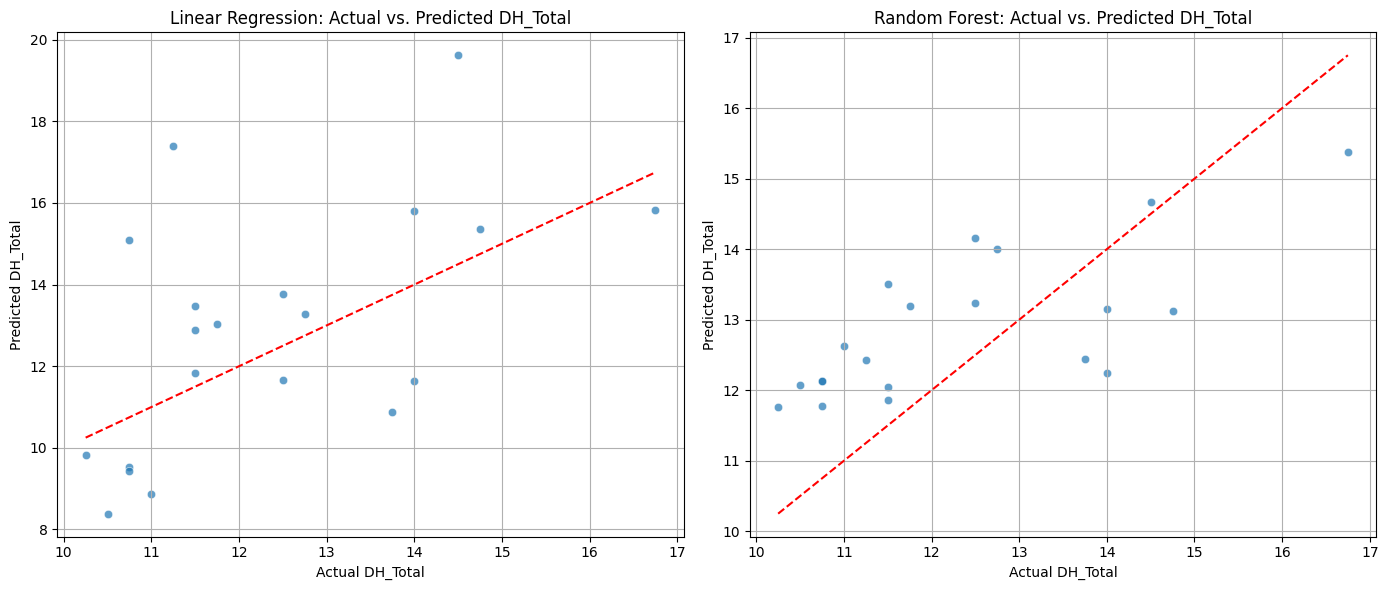

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Biểu đồ cho Hồi quy tuyến tính
plt.subplot(1, 2, 1) # 1 hàng, 2 cột, biểu đồ thứ nhất
sns.scatterplot(x=y_test, y=y_pred_scaled, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--') # Đường y=x
plt.title('Linear Regression: Actual vs. Predicted DH_Total')
plt.xlabel('Actual DH_Total')
plt.ylabel('Predicted DH_Total')
plt.grid(True)

# Biểu đồ cho Random Forest
plt.subplot(1, 2, 2) # 1 hàng, 2 cột, biểu đồ thứ hai
sns.scatterplot(x=y_test, y=rf_y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--') # Đường y=x
plt.title('Random Forest: Actual vs. Predicted DH_Total')
plt.xlabel('Actual DH_Total')
plt.ylabel('Predicted DH_Total')
plt.grid(True)

plt.tight_layout() # Đảm bảo các biểu đồ không chồng chéo
plt.show()

#Mô hình ANN


In [39]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


## 1. Nạp thư viện

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## 2. Đọc tập dữ liệu FASHION MNIST

In [41]:
# Đường dẫn tới các file dữ liệu (từ biến 'path' đã có)
import os
train_file = os.path.join(path, 'fashion-mnist_train.csv')
test_file = os.path.join(path, 'fashion-mnist_test.csv')

# Đọc dữ liệu huấn luyện
df_fashion_train = pd.read_csv(train_file)
print("Dữ liệu huấn luyện:")
display(df_fashion_train.head())
print(f"Kích thước dữ liệu huấn luyện: {df_fashion_train.shape}")

# Đọc dữ liệu kiểm tra
df_fashion_test = pd.read_csv(test_file)
print("\nDữ liệu kiểm tra:")
display(df_fashion_test.head())
print(f"Kích thước dữ liệu kiểm tra: {df_fashion_test.shape}")

Dữ liệu huấn luyện:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Kích thước dữ liệu huấn luyện: (60000, 785)

Dữ liệu kiểm tra:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Kích thước dữ liệu kiểm tra: (10000, 785)


## 3. Xử lý dữ liệu

In [42]:
# Tách features (X) và labels (y) cho tập huấn luyện
X_train_full = df_fashion_train.drop('label', axis=1)
y_train_full = df_fashion_train['label']

# Tách features (X) và labels (y) cho tập kiểm tra
X_test_full = df_fashion_test.drop('label', axis=1)
y_test_full = df_fashion_test['label']

print("Kiểm tra dữ liệu thiếu trong tập huấn luyện:")
display(X_train_full.isnull().sum().sum())
print("Kiểm tra dữ liệu thiếu trong tập kiểm tra:")
display(X_test_full.isnull().sum().sum())

Kiểm tra dữ liệu thiếu trong tập huấn luyện:


np.int64(0)

Kiểm tra dữ liệu thiếu trong tập kiểm tra:


np.int64(0)

In [43]:
# Chuẩn hóa giá trị pixel về khoảng [0, 1]
X_train_scaled = X_train_full / 255.0
X_test_scaled = X_test_full / 255.0

print("5 dòng đầu tiên của X_train sau khi chuẩn hóa:")
display(X_train_scaled.head())

5 dòng đầu tiên của X_train sau khi chuẩn hóa:


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.019608,0.0,0.0,...,0.000000,0.0,0.0,0.117647,0.168627,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.003922,0.007843,0.0,0.0,0.000000,0.0,0.0,...,0.011765,0.0,0.0,0.000000,0.000000,0.003922,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


In [44]:
# Reshape dữ liệu ảnh từ 1D (784 pixel) sang 2D (28x28) để trực quan hóa (tùy chọn)
# Đối với ANN ban đầu, thường sử dụng 1D. Tuy nhiên, nếu là CNN sẽ cần 3D (28, 28, 1)
# Ở đây chúng ta sẽ giữ 1D cho đầu vào ANN trực tiếp.
image_size = int(np.sqrt(X_train_scaled.shape[1])) # Lấy kích thước cạnh của ảnh (28)
print(f"Kích thước ảnh: {image_size}x{image_size}")

# Mã hóa nhãn thành One-Hot Encoding
y_train_one_hot = to_categorical(y_train_full, num_classes=10)
y_test_one_hot = to_categorical(y_test_full, num_classes=10)

print("5 dòng đầu tiên của nhãn huấn luyện sau One-Hot Encoding:")
display(y_train_one_hot[:5])

# Tách tập huấn luyện thành huấn luyện và validation (80/20) để theo dõi overfitting
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled, y_train_one_hot, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Kích thước tập huấn luyện X_train: {X_train.shape}")
print(f"Kích thước tập validation X_val: {X_val.shape}")
print(f"Kích thước tập huấn luyện y_train: {y_train.shape}")
print(f"Kích thước tập validation y_val: {y_val.shape}")
print(f"Kích thước tập kiểm tra X_test: {X_test_scaled.shape}")
print(f"Kích thước tập kiểm tra y_test: {y_test_one_hot.shape}")

Kích thước ảnh: 28x28
5 dòng đầu tiên của nhãn huấn luyện sau One-Hot Encoding:


array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]])

Kích thước tập huấn luyện X_train: (48000, 784)
Kích thước tập validation X_val: (12000, 784)
Kích thước tập huấn luyện y_train: (48000, 10)
Kích thước tập validation y_val: (12000, 10)
Kích thước tập kiểm tra X_test: (10000, 784)
Kích thước tập kiểm tra y_test: (10000, 10)


## 4. Trực quan hóa dữ liệu

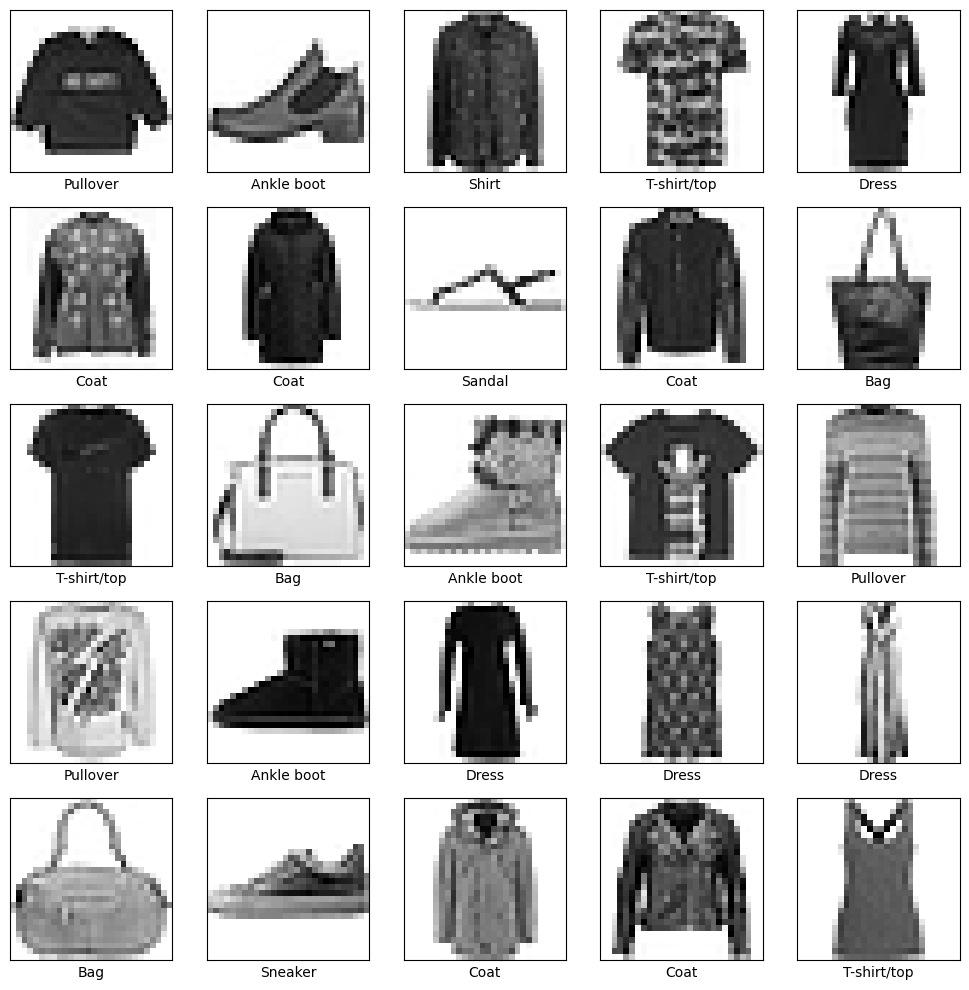

In [45]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # Reshape the 1D array (784 pixels) back to 2D (28x28) for plotting
    plt.imshow(X_train_full.iloc[i].values.reshape(28,28), cmap=plt.cm.binary)
    # Get the original label to find the class name
    label_index = y_train_full.iloc[i]
    plt.xlabel(class_names[label_index])
plt.tight_layout()
plt.show()

## 5. Xây dựng mô hình học ANN

In [46]:
# Xác định số lượng đặc trưng đầu vào (số pixel của ảnh)
input_shape = X_train.shape[1]
num_classes = y_train.shape[1] # Số lượng lớp đầu ra (10 loại quần áo)

model_ann_fashion = Sequential([
    Flatten(input_shape=(input_shape,)), # Lớp Flatten để chuyển ảnh 2D (hoặc 1D) thành vector 1D
    Dense(128, activation='relu'),       # Lớp ẩn đầu tiên với 128 nơ-ron, hàm kích hoạt ReLU
    Dropout(0.2),                        # Lớp Dropout để giảm overfitting
    Dense(64, activation='relu'),        # Lớp ẩn thứ hai với 64 nơ-ron, hàm kích hoạt ReLU
    Dropout(0.2),                        # Lớp Dropout thứ hai
    Dense(num_classes, activation='softmax') # Lớp đầu ra với 10 nơ-ron (cho 10 lớp), hàm kích hoạt softmax cho phân loại đa lớp
])

# Biên dịch mô hình
# Optimizer: Adam (phổ biến và hiệu quả)
# Loss function: categorical_crossentropy (phù hợp cho phân loại đa lớp với One-Hot Encoding)
# Metrics: accuracy (để đánh giá)
model_ann_fashion.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Mô hình ANN đã được định nghĩa và biên dịch.")
model_ann_fashion.summary()

Mô hình ANN đã được định nghĩa và biên dịch.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Huấn luyện ANN model

In [47]:
# Định nghĩa Early Stopping callback
# monitor='val_loss' theo dõi loss trên tập validation
# patience=10: nếu val_loss không cải thiện trong 10 epoch liên tiếp thì dừng huấn luyện
# restore_best_weights=True: khôi phục trọng số từ epoch có val_loss tốt nhất
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Huấn luyện mô hình
history_fashion = model_ann_fashion.fit(
    X_train, y_train,
    epochs=50,  # Có thể đặt số epoch cao, EarlyStopping sẽ giúp dừng lại đúng lúc
    batch_size=128,
    validation_data=(X_val, y_val), # Sử dụng tập validation đã tách
    callbacks=[early_stopping_callback], # Thêm callback EarlyStopping
    verbose=1 # Hiển thị log huấn luyện
)

print("Mô hình ANN Fashion MNIST đã được huấn luyện.")

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7530 - loss: 0.6989 - val_accuracy: 0.8352 - val_loss: 0.4494
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8343 - loss: 0.4656 - val_accuracy: 0.8583 - val_loss: 0.3849
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8521 - loss: 0.4157 - val_accuracy: 0.8643 - val_loss: 0.3716
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8624 - loss: 0.3870 - val_accuracy: 0.8737 - val_loss: 0.3509
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8662 - loss: 0.3694 - val_accuracy: 0.8731 - val_loss: 0.3412
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8725 - loss: 0.3558 - val_accuracy: 0.8749 - val_loss: 0.3405
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8774 - loss: 0.3446 - val_accuracy: 0.8681 - val_loss: 0.3517
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8814 - loss: 0.3297 - val_accuracy: 0

## 7. Đánh giá ANN model

Loss trên tập kiểm tra: 0.3019
Độ chính xác (Accuracy) trên tập kiểm tra: 0.8885
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Báo cáo phân loại:
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.86      0.83      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.83      0.81      0.82      1000
       Dress       0.88      0.92      0.90      1000
        Coat       0.79      0.88      0.83      1000
      Sandal       0.96      0.95      0.96      1000
       Shirt       0.78      0.62      0.69      1000
     Sneaker       0.94      0.93      0.93      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Ma trận nhầm lẫn:


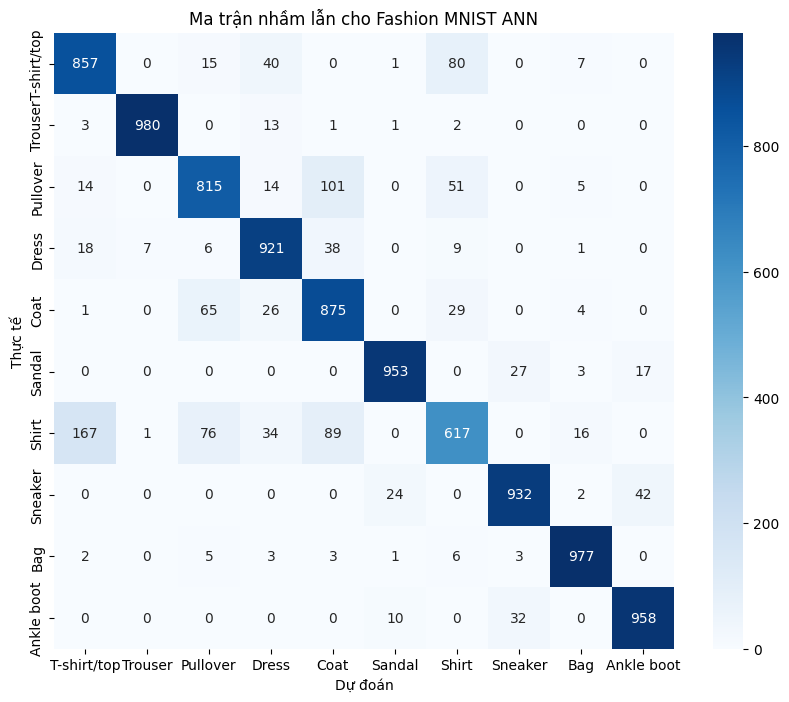

In [48]:
# Đánh giá mô hình trên tập kiểm tra
loss, accuracy = model_ann_fashion.evaluate(X_test_scaled, y_test_one_hot, verbose=0)

print(f"Loss trên tập kiểm tra: {loss:.4f}")
print(f"Độ chính xác (Accuracy) trên tập kiểm tra: {accuracy:.4f}")

# Dự đoán nhãn trên tập kiểm tra
y_pred_fashion_probs = model_ann_fashion.predict(X_test_scaled)
y_pred_fashion = np.argmax(y_pred_fashion_probs, axis=1)
y_true_fashion = np.argmax(y_test_one_hot, axis=1)

# Hiển thị báo cáo phân loại
print("\nBáo cáo phân loại:")
print(classification_report(y_true_fashion, y_pred_fashion, target_names=class_names))

# Hiển thị ma trận nhầm lẫn
print("\nMa trận nhầm lẫn:")
cm = confusion_matrix(y_true_fashion, y_pred_fashion)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn cho Fashion MNIST ANN')
plt.show()

## 8. Dự báo ảnh mới

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


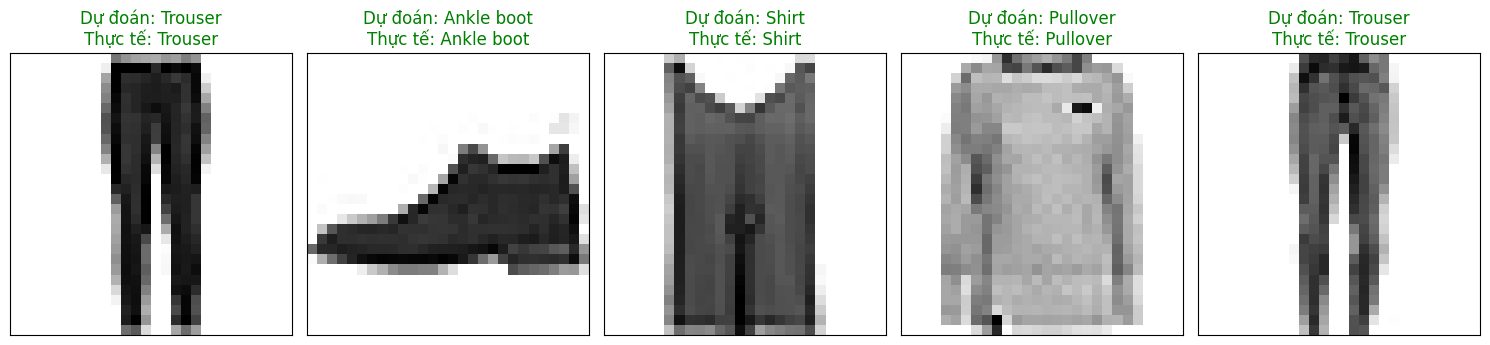

In [49]:
import random

# Lấy một vài ảnh ngẫu nhiên từ tập kiểm tra
num_samples = 5
r_indices = random.sample(range(len(X_test_scaled)), num_samples)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(r_indices):
    img_data = X_test_scaled.iloc[idx].values.reshape(28, 28)
    true_label_idx = y_true_fashion[idx]

    # Dự đoán cho ảnh này
    prediction_probs = model_ann_fashion.predict(X_test_scaled.iloc[[idx]])
    predicted_label_idx = np.argmax(prediction_probs)

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img_data, cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    color = 'green' if predicted_label_idx == true_label_idx else 'red'
    title = f"Dự đoán: {class_names[predicted_label_idx]}\nThực tế: {class_names[true_label_idx]}"
    plt.title(title, color=color)

plt.tight_layout()
plt.show()